In [ ]:
import dolphindb as ddb
import pandas as pd
#该模块查询出沪深300在2026年3月2日成分权重前30位的股票的基本信息，并输出到csv文件中
s = ddb.session()
s.connect("******", "*****", "******", "******")
WEIGHT_CSV_PATH = r"..\数据\沪深300成分股.csv"
df_weights = pd.read_csv(WEIGHT_CSV_PATH)
df_top30 = df_weights.head(30).reset_index(drop=True)
top30_codes = df_top30["con_code"].tolist()
code_str = "', '".join(top30_codes)
query = f'''
db = database("******")
stock_info=loadTable(db, "stock_info_table")
select * 
from stock_info 
where ts_code in ('{code_str}')
'''
result_df = s.run(query)
final_df = pd.merge(
    df_top30[["con_code", "weight"]],  # 权重数据（已排序）
    result_df,
    left_on="con_code",  # CSV中的代码列
    right_on="ts_code",  # 数据库中的代码列
    how="left"
).drop(columns=["ts_code"])  # 去掉重复的代码列
final_df.to_csv(r"..\数据\沪深300前30成分股信息.csv", index=False, encoding="utf-8-sig")

In [4]:
#这个模块用于将获得的前20只股票的数据进行可视化，绘制原始价格序列与对数收益率序列，观察噪声特征
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
import warnings
warnings.filterwarnings('ignore') # 关闭代码运行时的无关警告

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'WenQuanYi Micro Hei']
plt.rcParams['axes.unicode_minus'] = False#让图表里的负号正常显示

# 数据目录
data_dir = Path("../数据/沪深300权重前20位股票3年基本数据") 

# 读取所有CSV文件
all_stocks = {}#存放20只股票信息，字典
csv_files = list(data_dir.glob("*.csv"))#找到文件夹里所有后缀是 .csv 的文件

for csv_file in csv_files:
    stock_code = csv_file.stem  # 获取文件名（不含扩展名）
    try:
        df = pd.read_csv(csv_file)
        
        # 列名：trade_date, open, high, low, close, volume, amount
        if 'trade_date' in df.columns:
            df['trade_date'] = pd.to_datetime(df['trade_date'])
            df = df.sort_values('trade_date').reset_index(drop=True)
            #按日期从小到大排序，重置行号，保证数据顺序正确
            # 计算对数收益率
            df['log_return'] = np.log(df['close'] / df['close'].shift(1))
            
            # 涨跌幅（%）【基于除权后的昨收计算的涨跌幅：（今收-除权昨收）/除权昨收 】
            df['pct_return'] = df['pct_chg']
            
            all_stocks[stock_code] = df
            print(f"加载 {stock_code}: {len(df)} 条记录, 日期范围 {df['trade_date'].min().date()} 至 {df['trade_date'].max().date()}")
        else:
            print(f"跳过 {stock_code}: 缺少date列")
    except Exception as e:
        print(f"加载 {stock_code} 失败: {e}")

加载 000333.SZ: 725 条记录, 日期范围 2023-03-01 至 2026-02-27
加载 002475.SZ: 725 条记录, 日期范围 2023-03-01 至 2026-02-27
加载 002594.SZ: 725 条记录, 日期范围 2023-03-01 至 2026-02-27
加载 300059.SZ: 725 条记录, 日期范围 2023-03-01 至 2026-02-27
加载 300308.SZ: 725 条记录, 日期范围 2023-03-01 至 2026-02-27
加载 300502.SZ: 725 条记录, 日期范围 2023-03-01 至 2026-02-27
加载 300750.SZ: 725 条记录, 日期范围 2023-03-01 至 2026-02-27
加载 600030.SH: 725 条记录, 日期范围 2023-03-01 至 2026-02-27
加载 600036.SH: 725 条记录, 日期范围 2023-03-01 至 2026-02-27
加载 600276.SH: 725 条记录, 日期范围 2023-03-01 至 2026-02-27
加载 600519.SH: 725 条记录, 日期范围 2023-03-01 至 2026-02-27
加载 600900.SH: 725 条记录, 日期范围 2023-03-01 至 2026-02-27
加载 601166.SH: 725 条记录, 日期范围 2023-03-01 至 2026-02-27
加载 601318.SH: 725 条记录, 日期范围 2023-03-01 至 2026-02-27
加载 601398.SH: 725 条记录, 日期范围 2023-03-01 至 2026-02-27
加载 601899.SH: 725 条记录, 日期范围 2023-03-01 至 2026-02-27
加载 603259.SH: 725 条记录, 日期范围 2023-03-01 至 2026-02-27
加载 688041.SH: 715 条记录, 日期范围 2023-03-01 至 2026-02-27
加载 688256.SH: 725 条记录, 日期范围 2023-03-01 至 2026-02-27
加载 688981.SH

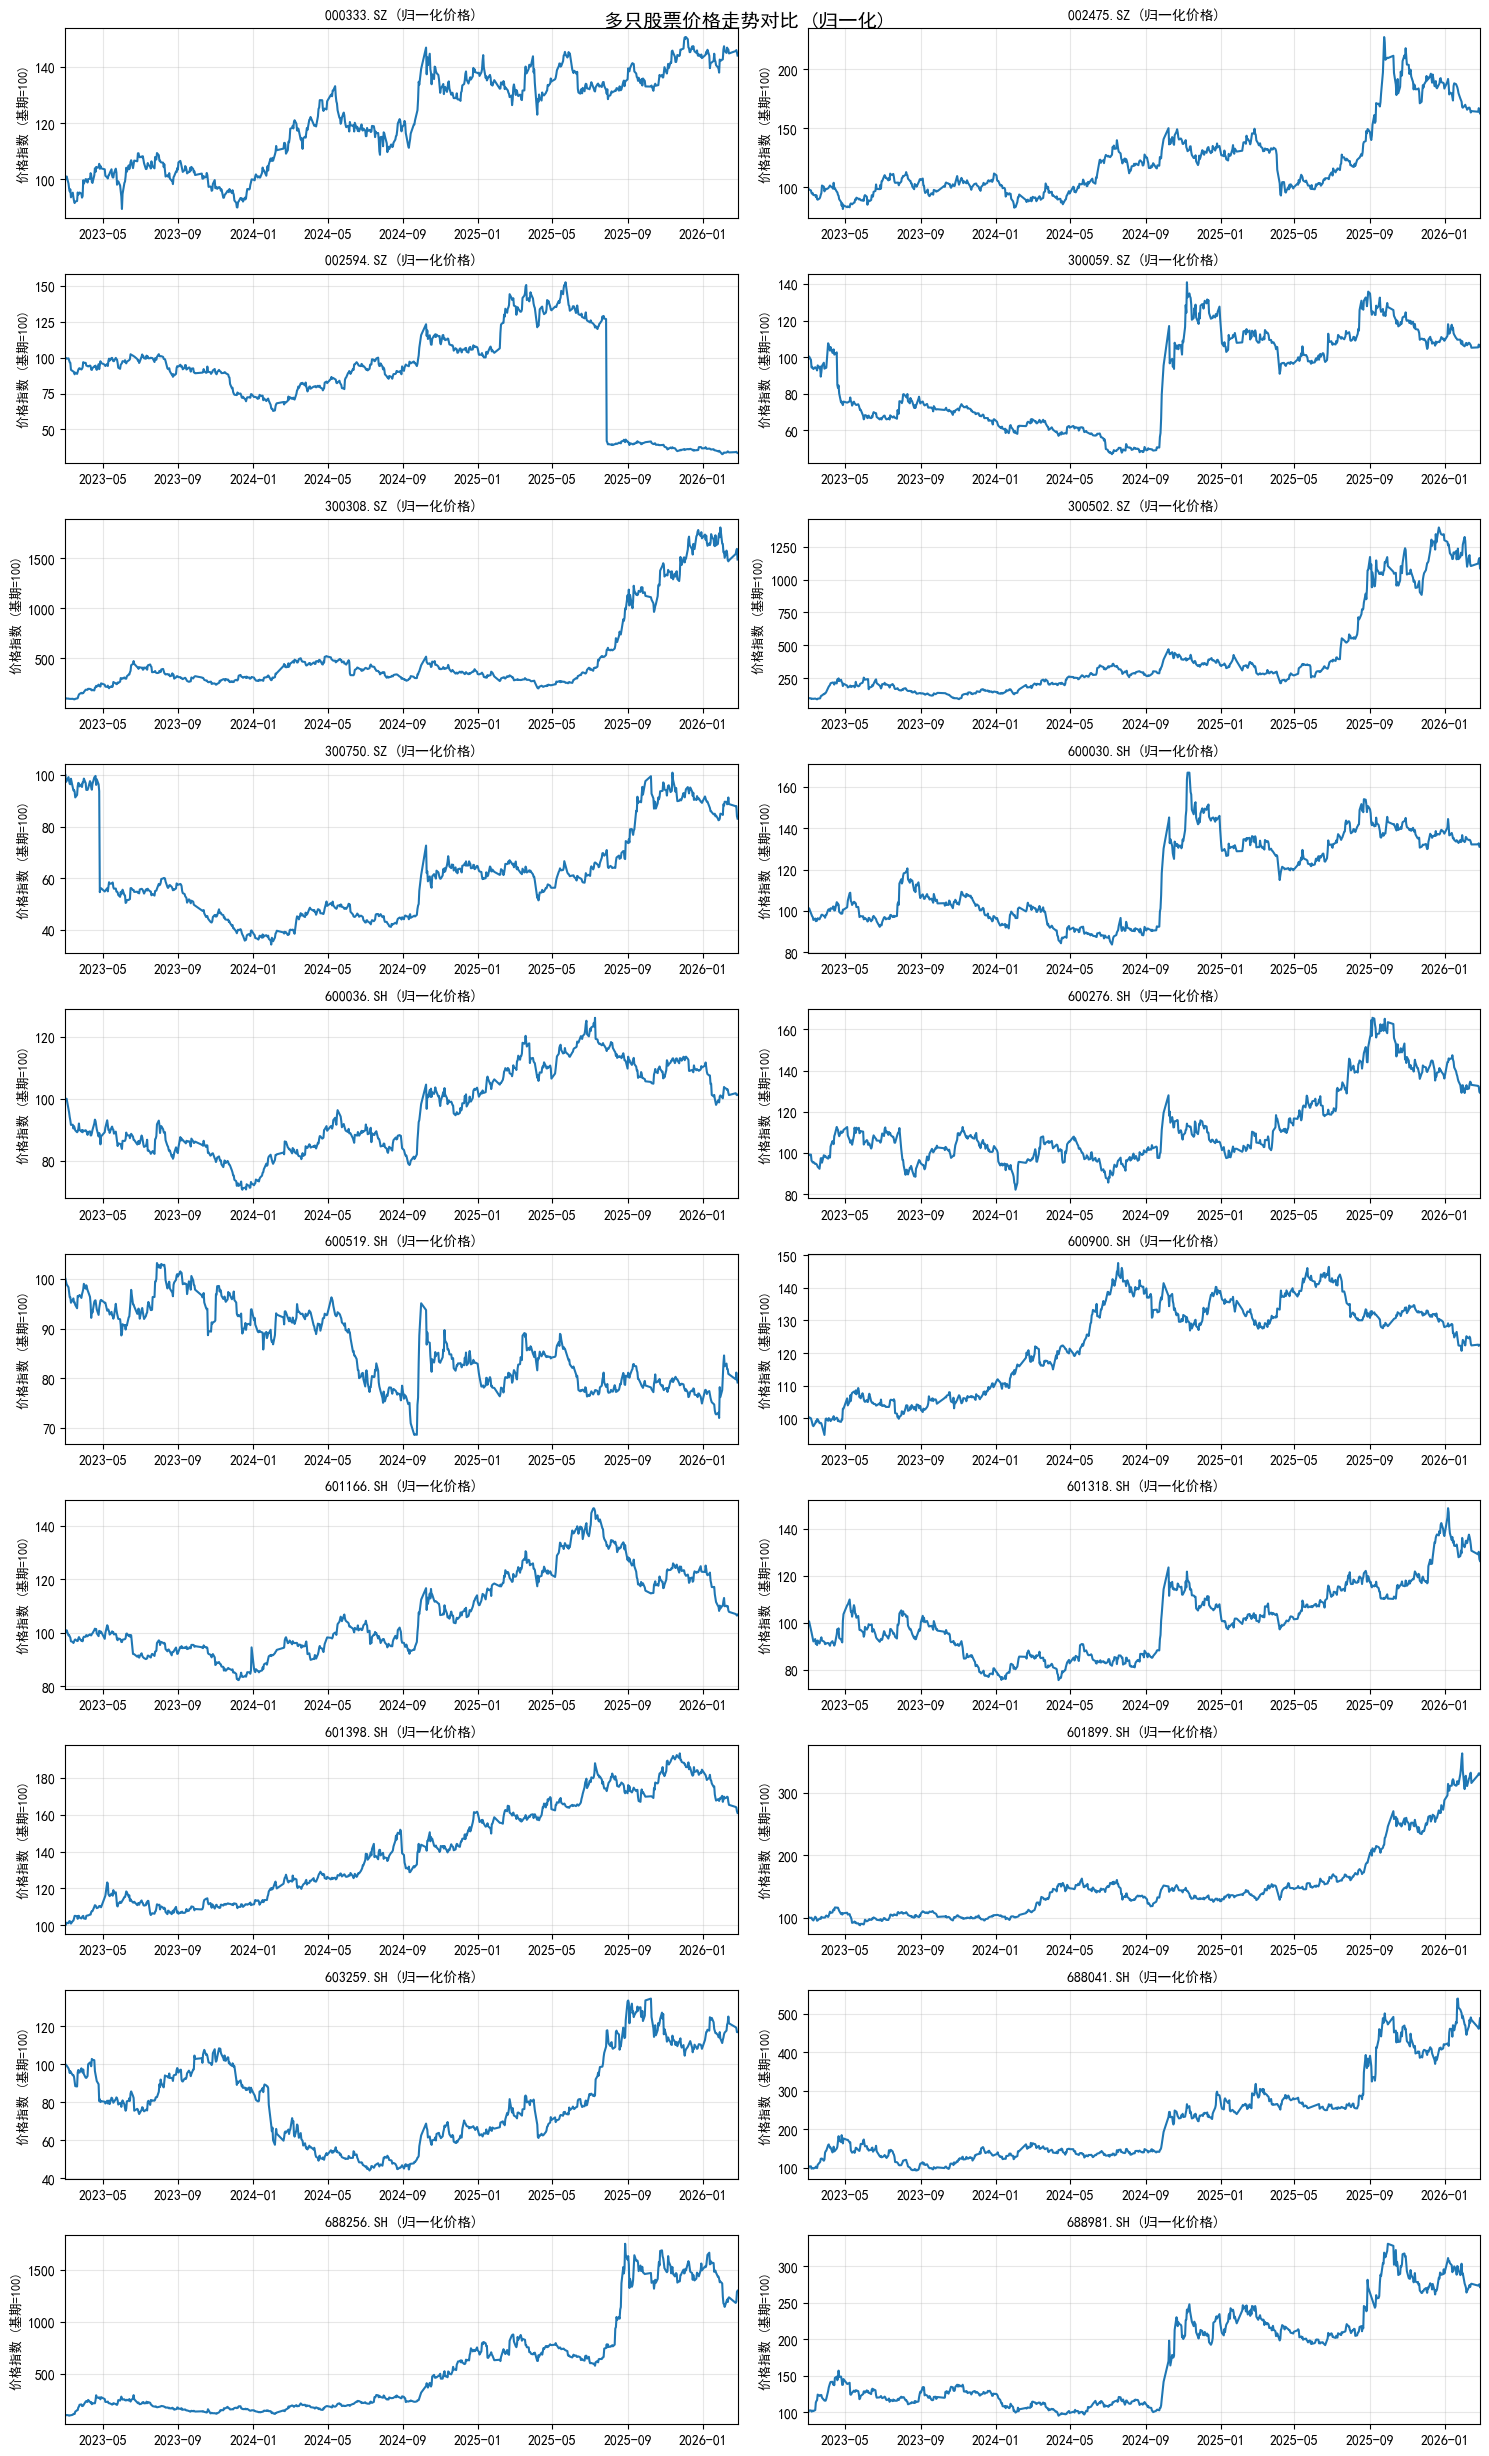

In [ ]:
#绘制多只股票归一化后的价格对比，用于观察不同股票的波动特征差异
def plot_normalized_prices(stocks_dict, n_stocks):
    # 选择前n_stocks只股票
    codes = list(stocks_dict.keys())[:n_stocks]
    
    fig, axes = plt.subplots(10, 2, figsize=(15, 25))
    axes = axes.flatten()#把二维的子图矩阵拉平成一维列表
    
    for i, code in enumerate(codes):
        df = stocks_dict[code]
        # 归一化：以第一天价格为基准
        normalized = df['close'] / df['close'].iloc[0] * 100
        
        axes[i].plot(df['trade_date'], normalized, linewidth=1.5)
        axes[i].set_title(f'{code} (归一化价格)', fontsize=10)
        axes[i].set_ylabel('价格指数 (基期=100)', fontsize=9)
        axes[i].grid(True, alpha=0.3)
        axes[i].set_xlim(df['trade_date'].min(), df['trade_date'].max())
        
    plt.suptitle('多只股票价格走势对比 (归一化)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(r'../图表/多只股票价格走势对比 (归一化).png', dpi=150, bbox_inches='tight')
    plt.show()

plot_normalized_prices(all_stocks, 20)

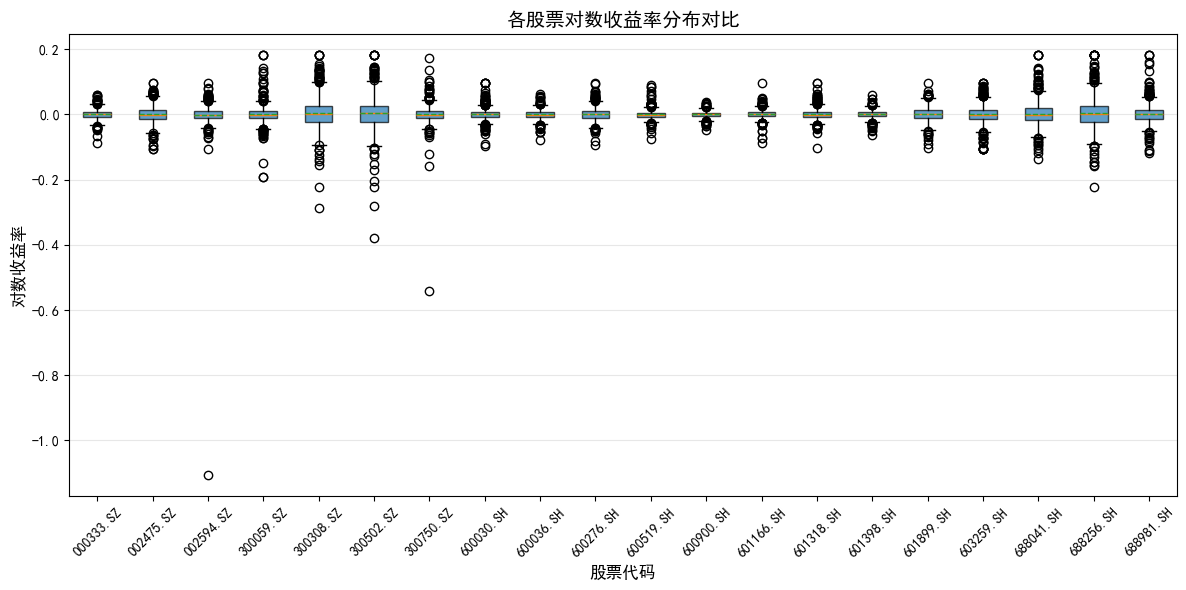


=== 股票波动特征汇总 ===
     code      标准差         偏度         峰度     最大回撤率
000333.SZ 0.014929  -0.117058   3.198141 -0.183056
002475.SZ 0.025937   0.100380   1.625060 -0.380963
002594.SZ 0.045604 -19.664470 477.083535 -0.785062
300059.SZ 0.028590   0.903121  15.242445 -0.564875
300308.SZ 0.046664   0.154446   4.213302 -0.616462
300502.SZ 0.051392  -0.510305   6.961374 -0.643965
300750.SZ 0.031240  -6.835357 126.774597 -0.658191
600030.SH 0.017889   0.904242   7.795265 -0.311353
600036.SH 0.013971   0.025038   3.477960 -0.293333
600276.SH 0.019531   0.405138   3.143966 -0.270643
600519.SH 0.014208   1.129419   8.231151 -0.335266
600900.SH 0.009505  -0.122491   2.398904 -0.182079
601166.SH 0.013271  -0.186663   9.177916 -0.274065
601318.SH 0.016700   0.710660   6.115604 -0.312090
601398.SH 0.011935  -0.235257   3.470910 -0.167268
601899.SH 0.022047  -0.153578   1.826050 -0.273241
603259.SH 0.027539  -0.093862   2.714655 -0.594300
688041.SH 0.037283   0.902266   3.795138 -0.497114
688256.SH 0.0

In [ ]:
# 绘制多只股票的收益率箱线图，对比波动特征
def plot_returns_boxplot(stocks_dict, n_stocks=15):
    codes = list(stocks_dict.keys())[:n_stocks]
    
    returns_list = []
    for code in codes:
        df = stocks_dict[code]
        returns_clean = df['log_return'].dropna()#去除空值
        returns_list.append(returns_clean.values)
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    bp = ax.boxplot(returns_list, labels=codes, patch_artist=True, 
                     showmeans=True, meanline=True)
    
    # 设置颜色
    for box in bp['boxes']:
        box.set_alpha(0.7)
    
    ax.set_title('各股票对数收益率分布对比', fontsize=14, fontweight='bold')
    ax.set_ylabel('对数收益率', fontsize=12)
    ax.set_xlabel('股票代码', fontsize=12)
    ax.grid(True, alpha=0.3, axis='y')
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.savefig('../图表/收益率箱线图.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # 输出统计汇总
    stats_summary = []
    for i, code in enumerate(codes):
        stats_summary.append({
            'code': code,
            '标准差': returns_list[i].std(),
            '偏度': pd.Series(returns_list[i]).skew(),
            '峰度': pd.Series(returns_list[i]).kurtosis(),
            '最大回撤率': (stocks_dict[code]['close'] / stocks_dict[code]['close'].cummax() - 1).min()
        })
    
    summary_df = pd.DataFrame(stats_summary)
    print("\n=== 股票波动特征汇总 ===")
    print(summary_df.to_string(index=False))

plot_returns_boxplot(all_stocks, 20)


=== 噪声特征分析结果 ===
     code  收益率标准差（波动率）         偏度         峰度   一阶自相关系数   五阶自相关系数  波动率聚集变异系数    极端值比例      噪声信号比
300502.SZ     0.051427  -0.510305   6.961374  0.061264 -0.032198   0.358737 0.015193  15.615629
688256.SH     0.048270   0.615142   3.021749  0.067549 -0.018254   0.351319 0.024862  13.624166
300308.SZ     0.046696   0.154446   4.213302  0.034988 -0.049501   0.314066 0.015193  12.524264
002594.SZ     0.045635 -19.664470 477.083535  0.023705 -0.017342   1.499239 0.001381  30.328953
688041.SH     0.037309   0.902266   3.795138  0.056154 -0.114482   0.391989 0.016807  16.804401
300750.SZ     0.031261  -6.835357 126.774597 -0.012560 -0.003920   0.782025 0.011050 121.912925
688981.SH     0.029518   1.437469   8.907827  0.067324 -0.044345   0.536982 0.016713  21.225700
300059.SZ     0.028610   0.903121  15.242445  0.090374  0.026161   0.632282 0.020718 365.726460
603259.SH     0.027558  -0.093862   2.714655  0.114634  0.079425   0.337794 0.022099 127.571194
002475.SZ     0.025954

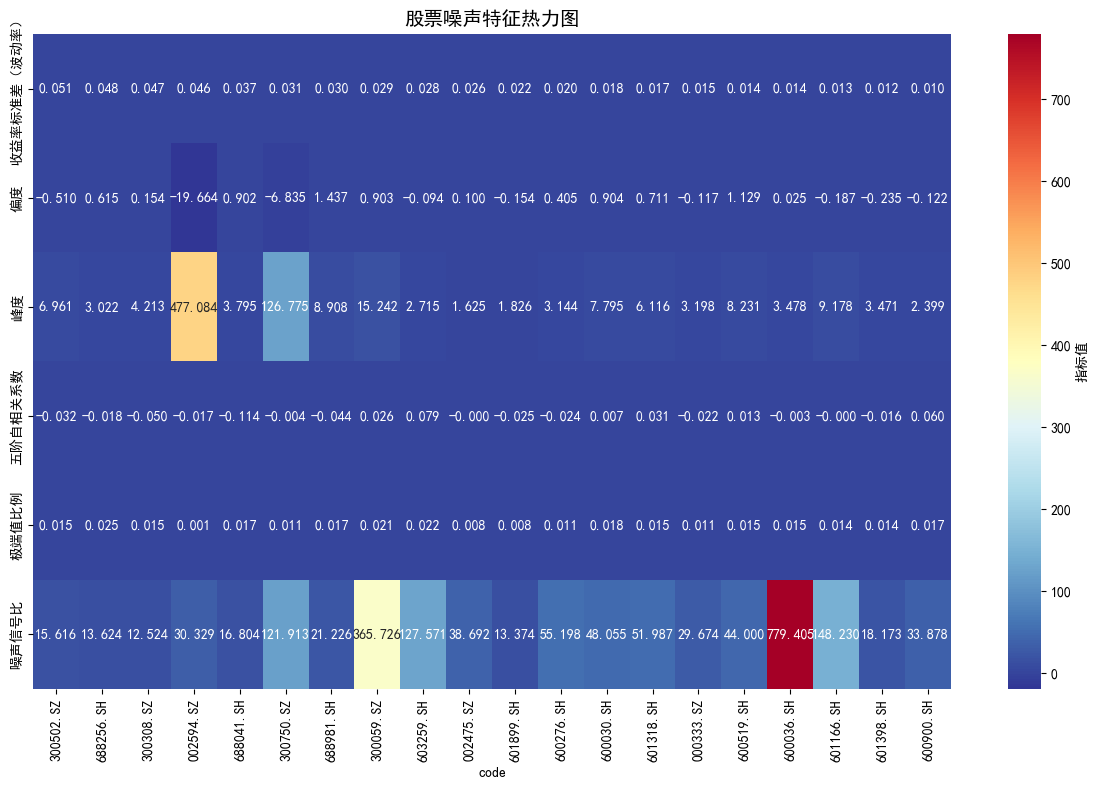

In [8]:
#量化分析每只股票的噪声特征
def analyze_noise_characteristics(stocks_dict):
    results = []
    
    for code, df in stocks_dict.items():
        returns = df['log_return'].dropna()
        
        # 1. 基础统计
        std = returns.std()# 波动率 = 噪声强度
        skew = returns.skew()# 偏度 = 涨跌不对称性
        kurt = returns.kurtosis()# 峰度 = 极端值多少
        
        # 2. 自相关性（衡量噪声的持续性）
        from scipy.stats import pearsonr
        autocorr_1 = returns.autocorr(lag=1) # 今日与昨日相关性
        autocorr_5 = returns.autocorr(lag=5)# 今日与5日前相关性
        #接近 0 = 市场有效、随机游走、纯噪声
        #不等于 0 = 有趋势、有规律
        # 3. 波动率聚集特征（用GARCH类型效应，简化为滚动标准差变异系数）
        rolling_std = returns.rolling(window=20).std().dropna()
        vol_clustering = rolling_std.std() / rolling_std.mean()  # CV越大，波动聚集越明显
        
        # 4. 极端值频率（超过3倍标准差的交易日占比）
        extreme_ratio = (abs(returns) > 3 * std).sum() / len(returns)
        
        # 5. 信息比率的倒数（噪声/信号）
        noise_to_signal = returns.std() / abs(returns.mean()) if returns.mean() != 0 else np.inf
        
        results.append({
            'code': code,
            '收益率标准差（波动率）': std,
            '偏度': skew,
            '峰度': kurt,
            '一阶自相关系数': autocorr_1,
            '五阶自相关系数': autocorr_5,
            '波动率聚集变异系数': vol_clustering,
            '极端值比例': extreme_ratio,
            '噪声信号比': noise_to_signal
        })
    
    return pd.DataFrame(results)

# 执行分析
noise_analysis = analyze_noise_characteristics(all_stocks)
noise_analysis = noise_analysis.sort_values('收益率标准差（波动率）', ascending=False)

print("\n=== 噪声特征分析结果 ===")
print(noise_analysis.to_string(index=False))

# 保存结果
noise_analysis.to_csv('../数据/噪声特征.csv', index=False, encoding='utf-8-sig')

# 绘制噪声特征热力图
fig, ax = plt.subplots(figsize=(12, 8))
# 选择数值列
numeric_cols = ['收益率标准差（波动率）', '偏度', '峰度', '五阶自相关系数', '极端值比例','噪声信号比']
heatmap_data = noise_analysis.set_index('code')[numeric_cols]

import seaborn as sns
sns.heatmap(heatmap_data.T, annot=True, fmt='.3f', cmap='RdYlBu_r', ax=ax, 
            cbar_kws={'label': '指标值'})
ax.set_title('股票噪声特征热力图', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../图表/噪声热力图.png', dpi=150, bbox_inches='tight')
plt.show()